In [1]:
# Constants
FULL_LEVEL = 8
WINDOW_SIZE = 4096
WINDOW_STEP = 2048
WINDOW_LEVEL = 7
MOTHER_WAVELET = "haar"

In [2]:
import io
import math
from enum import Enum

import numpy as np
import pandas as pd
import pywt
from Bio import Entrez, SeqIO
import Bio
import matplotlib.pyplot as plt
%matplotlib inline 

ACCESSION = "NC_000913.3"  # E. coli K-12 MG1655 complete genome
EMAIL = "daniel_mcgonigle1@student.uml.edu"  # NCBI asks for an email

Entrez.email = EMAIL

In [3]:
def fetch_genbank_record(accession: str) -> Bio.SeqRecord.SeqRecord:
    """
    Fetch a nucleotide sequence record from NCBI and parse it into a Biopython SeqRecord.

    Parameters
    ----------
    accession : str
        RefSeq or GenBank accession for the genome of interest.

    Returns
    -------
    Bio.SeqRecord.SeqRecord
        Parsed record containing the DNA sequence and feature annotations.
    """
    with Entrez.efetch(db="nuccore", id=accession, rettype="gbwithparts", retmode="text") as handle:
        text = handle.read()
    return SeqIO.read(io.StringIO(text), "genbank")


class SignalType(str, Enum):
    """Signal domain choices for genome-derived indicator signals."""

    FULL = "full"
    CDS = "cds"
    NONCDS = "noncds"


record = fetch_genbank_record(ACCESSION)
sequence = str(record.seq).upper()
genome_len = len(sequence)

print(f"Record ID: {record.id}")
print(f"Description: {record.description}")
print(f"Genome length: {genome_len:,} bp")
print(f"Annotated feature types: {sorted({feat.type for feat in record.features})}")

Record ID: NC_000913.3
Description: Escherichia coli str. K-12 substr. MG1655, complete genome
Genome length: 4,641,652 bp
Annotated feature types: ['CDS', 'gene', 'misc_feature', 'mobile_element', 'ncRNA', 'rRNA', 'rep_origin', 'source', 'tRNA']


In [4]:
def build_cds_mask(record: Bio.SeqRecord.SeqRecord, sequence_length: int) -> np.ndarray:
    """
    Build a boolean mask marking every base position covered by a CDS annotation.

    Parameters
    ----------
    record : Bio.SeqRecord.SeqRecord
        Record whose CDS annotations define coding positions.
    sequence_length : int
        Length of the full genome sequence.

    Returns
    -------
    np.ndarray
        Boolean mask whose True entries indicate genome positions covered by at
        least one CDS interval.
    """
    cds_mask = np.zeros(sequence_length, dtype=bool)
    for feat in record.features:
        if feat.type != "CDS":
            continue

        parts = getattr(feat.location, "parts", [feat.location])
        for part in parts:
            start = int(part.start)
            end = int(part.end)
            cds_mask[start:end] = True

    return cds_mask


def extract_signal_sequence(
    sequence: str,
    record: Bio.SeqRecord.SeqRecord,
    signal_type: SignalType,
) -> str:
    """
    Extract the sequence corresponding to a requested signal domain.

    Parameters
    ----------
    sequence : str
        Full nucleotide sequence.
    record : Bio.SeqRecord.SeqRecord
        Record whose CDS annotations define coding and non-coding positions.
    signal_type : SignalType
        Which sequence domain to extract: full genome, CDS-only, or the
        complement of CDS.

    Returns
    -------
    str
        Sequence associated with the selected signal type.

    Notes
    -----
    SignalType.CDS is built by concatenating CDS feature intervals in record order.
    SignalType.NONCDS is built as the complement of the CDS mask across the full genome,
    so it cannot exceed the full-genome length.
    """
    if signal_type == SignalType.FULL:
        return sequence

    cds_mask = build_cds_mask(record, len(sequence))

    if signal_type == SignalType.CDS:
        return "".join(np.asarray(list(sequence))[cds_mask])
    if signal_type == SignalType.NONCDS:
        return "".join(np.asarray(list(sequence))[~cds_mask])

    raise ValueError(f"Unsupported signal_type: {signal_type}")


def create_binary_signal(
    bases: str,
    sequence: str,
    record: Bio.SeqRecord.SeqRecord,
    signal_type: SignalType = SignalType.FULL,
) -> np.ndarray:
    """
    Create a binary nucleotide indicator signal.

    Parameters
    ----------
    bases : str
        One or more nucleotide letters to mark with 1s, for example "GC" or "A".
    sequence : str
        Full sequence from which the signal is built.
    record : Bio.SeqRecord.SeqRecord
        Record whose CDS annotations determine the selected signal domain.
    signal_type : SignalType, default SignalType.FULL
        Which domain to encode: full genome, CDS-only, or non-CDS as the
        complement of CDS.

    Returns
    -------
    np.ndarray
        One-dimensional int8 array of 0s and 1s.
    """
    selected_bases = {base.upper() for base in bases if not base.isspace()}
    if not selected_bases:
        raise ValueError("bases must contain at least one nucleotide letter")

    sequence_to_encode = extract_signal_sequence(sequence, record, signal_type)

    return np.fromiter(
        (1 if base in selected_bases else 0 for base in sequence_to_encode),
        dtype=np.int8,
    )

In [5]:
def max_wavelet_level(signal_length: int, wavelet: str | pywt.Wavelet) -> int:
    """
    Compute the largest admissible discrete wavelet decomposition level.
    """
    if signal_length <= 0:
        raise ValueError("signal_length must be positive")

    wavelet_obj = pywt.Wavelet(wavelet) if isinstance(wavelet, str) else wavelet
    return pywt.dwt_max_level(signal_length, wavelet_obj.dec_len)


def compute_wavelet_decomposition(
    signal: np.ndarray,
    wavelet: str | pywt.Wavelet = "haar",
    level: int | None = None,
    mode: str = "periodization",
) -> dict:
    """
    Compute a multilevel one-dimensional discrete wavelet decomposition.

    Parameters
    ----------
    signal : np.ndarray
        One-dimensional input signal.
    wavelet : str | pywt.Wavelet, default "haar"
        Wavelet family to use.
    level : int | None, optional
        Number of decomposition levels. If omitted, the maximum useful level is used.
    mode : str, default "periodization"
        Boundary-handling mode passed to PyWavelets.

    Returns
    -------
    dict
        Structured decomposition metadata including the original signal,
        approximation coefficients, and detail coefficients keyed by scale.
    """
    x = np.asarray(signal, dtype=float)
    if x.ndim != 1:
        raise ValueError("signal must be one-dimensional")
    if len(x) == 0:
        raise ValueError("signal must not be empty")

    wavelet_obj = pywt.Wavelet(wavelet) if isinstance(wavelet, str) else wavelet
    admissible_level = max_wavelet_level(len(x), wavelet_obj)
    use_level = admissible_level if level is None else min(level, admissible_level)
    if use_level < 1:
        raise ValueError("signal is too short for a multilevel decomposition")

    coeffs = pywt.wavedec(x, wavelet=wavelet_obj, level=use_level, mode=mode)
    detail_coeffs = {
        detail_level: coeffs[-detail_level]
        for detail_level in range(1, use_level + 1)
    }

    return {
        "signal": x,
        "signal_length": len(x),
        "wavelet": wavelet_obj,
        "mode": mode,
        "level": use_level,
        "coeffs": coeffs,
        "approximation": coeffs[0],
        "details": detail_coeffs,
    }


def reconstruct_multiscale_components(decomposition: dict) -> dict[str, dict[int, np.ndarray]]:
    """
    Reconstruct approximation and detail components back to signal length.

    Returns
    -------
    dict[str, dict[int, np.ndarray]]
        Dictionary with two keys:
        - "approximations": reconstructed approximation component at each level
        - "details": reconstructed detail component at each level

        Each reconstructed array is trimmed to the original signal length so it can
        be plotted directly against genome position or local index.
    """
    coeffs = decomposition["coeffs"]
    wavelet = decomposition["wavelet"]
    mode = decomposition["mode"]
    level = decomposition["level"]
    signal_length = decomposition["signal_length"]

    approximations = {}
    details = {}

    for target_level in range(1, level + 1):
        approx_coeffs = [np.zeros_like(arr) for arr in coeffs]
        detail_coeffs = [np.zeros_like(arr) for arr in coeffs]

        approx_coeffs[0] = coeffs[0].copy()
        for idx in range(1, level - target_level + 1):
            approx_coeffs[idx] = coeffs[idx].copy()

        detail_index = level - target_level + 1
        detail_coeffs[detail_index] = coeffs[detail_index].copy()

        approximations[target_level] = pywt.waverec(approx_coeffs, wavelet, mode=mode)[:signal_length]
        details[target_level] = pywt.waverec(detail_coeffs, wavelet, mode=mode)[:signal_length]

    return {"approximations": approximations, "details": details}

In [6]:
def summarize_wavelet_coefficients(decomposition: dict) -> pd.DataFrame:
    """
    Create a tidy summary table for approximation and detail coefficients.

    This is useful for checking coefficient counts, scale levels, and raw energies
    before building plots or comparisons.
    """
    rows = []

    approx = np.asarray(decomposition["approximation"])
    rows.append({
        "kind": "approximation",
        "level": decomposition["level"],
        "num_coeffs": len(approx),
        "mean": float(np.mean(approx)),
        "std": float(np.std(approx)),
        "energy": float(np.sum(np.square(approx))),
    })

    for level, coeffs in sorted(decomposition["details"].items()):
        detail = np.asarray(coeffs)
        rows.append({
            "kind": "detail",
            "level": level,
            "num_coeffs": len(detail),
            "mean": float(np.mean(detail)),
            "std": float(np.std(detail)),
            "energy": float(np.sum(np.square(detail))),
        })

    return pd.DataFrame(rows).sort_values(["kind", "level"]).reset_index(drop=True)


def compute_wavelet_energy(
    decomposition: dict,
    normalize: bool = True,
    include_approximation: bool = True,
) -> pd.DataFrame:
    """
    Compute coefficient energy by wavelet component.

    Parameters
    ----------
    decomposition : dict
        Output from compute_wavelet_decomposition.
    normalize : bool, default True
        If True, divide each component energy by the total included energy.
    include_approximation : bool, default True
        If True, include the final approximation coefficients in the output table.

    Returns
    -------
    pd.DataFrame
        Table that supports scale-energy plots, normalized comparisons, and
        entropy calculations.
    """
    rows = []

    if include_approximation:
        approx = np.asarray(decomposition["approximation"])
        rows.append({
            "kind": "approximation",
            "level": decomposition["level"],
            "energy": float(np.sum(np.square(approx))),
        })

    for level, coeffs in sorted(decomposition["details"].items()):
        detail = np.asarray(coeffs)
        rows.append({
            "kind": "detail",
            "level": level,
            "energy": float(np.sum(np.square(detail))),
        })

    energy_df = pd.DataFrame(rows).sort_values(["kind", "level"]).reset_index(drop=True)
    if normalize:
        total_energy = energy_df["energy"].sum()
        energy_df["relative_energy"] = energy_df["energy"] / total_energy if total_energy else 0.0

    return energy_df


def compute_scale_entropy(energy_df: pd.DataFrame, column: str = "relative_energy") -> float:
    """
    Compute Shannon entropy for an energy distribution across scales.
    """
    if column not in energy_df.columns:
        raise ValueError(f"column '{column}' not found in energy_df")

    probs = energy_df[column].to_numpy(dtype=float)
    probs = probs[probs > 0]
    if len(probs) == 0:
        return 0.0
    return float(-np.sum(probs * np.log2(probs)))


def compare_energy_profiles(
    energy_df_a: pd.DataFrame,
    energy_df_b: pd.DataFrame,
    column: str = "relative_energy",
    metric: str = "kl",
    epsilon: float = 1e-12,
) -> float:
    """
    Compare two scale-energy profiles.

    Supported metrics
    -----------------
    "kl"
        Kullback-Leibler divergence D_KL(a || b).
    "js"
        Jensen-Shannon divergence.
    "l2"
        Euclidean distance between profiles.
    """
    merged = pd.merge(
        energy_df_a[["kind", "level", column]],
        energy_df_b[["kind", "level", column]],
        on=["kind", "level"],
        how="inner",
        suffixes=("_a", "_b"),
    )
    if merged.empty:
        raise ValueError("energy profiles do not share any common components")

    a = merged[f"{column}_a"].to_numpy(dtype=float) + epsilon
    b = merged[f"{column}_b"].to_numpy(dtype=float) + epsilon
    a = a / a.sum()
    b = b / b.sum()

    if metric == "kl":
        return float(np.sum(a * np.log2(a / b)))
    if metric == "js":
        m = 0.5 * (a + b)
        return float(0.5 * np.sum(a * np.log2(a / m)) + 0.5 * np.sum(b * np.log2(b / m)))
    if metric == "l2":
        return float(np.linalg.norm(a - b))
    raise ValueError("metric must be one of {'kl', 'js', 'l2'}")

In [7]:
def generate_signal_windows(
    signal: np.ndarray,
    window_size: int,
    step: int | None = None,
    drop_incomplete: bool = False,
) -> list[dict]:
    """
    Split a signal into overlapping or non-overlapping windows.

    Returns
    -------
    list[dict]
        Each item stores window bounds and the corresponding signal slice so it can
        be passed into wavelet helper functions for localized analysis.
    """
    x = np.asarray(signal)
    if x.ndim != 1:
        raise ValueError("signal must be one-dimensional")
    if window_size <= 0:
        raise ValueError("window_size must be positive")

    step = window_size if step is None else step
    if step <= 0:
        raise ValueError("step must be positive")

    windows = []
    for start in range(0, len(x), step):
        end = start + window_size
        window = x[start:end]
        if len(window) < window_size and drop_incomplete:
            break
        if len(window) == 0:
            continue
        windows.append({
            "start": start,
            "end": min(end, len(x)),
            "signal": window,
        })
    return windows


def compute_windowed_wavelet_energy(
    signal: np.ndarray,
    window_size: int,
    step: int | None = None,
    wavelet: str | pywt.Wavelet = "haar",
    level: int | None = None,
    mode: str = "periodization",
    normalize: bool = True,
    include_approximation: bool = False,
) -> pd.DataFrame:
    """
    Compute scale-energy summaries over sliding windows.

    This prepares a tidy table suitable for heat maps, windowed line plots, and
    regional comparisons without prescribing a single visualization.
    """
    rows = []
    for window in generate_signal_windows(signal, window_size=window_size, step=step):
        decomposition = compute_wavelet_decomposition(
            window["signal"],
            wavelet=wavelet,
            level=level,
            mode=mode,
        )
        energy_df = compute_wavelet_energy(
            decomposition,
            normalize=normalize,
            include_approximation=include_approximation,
        )
        energy_df["window_start"] = window["start"]
        energy_df["window_end"] = window["end"]
        rows.append(energy_df)

    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def prepare_wavelet_artifacts(
    signal: np.ndarray,
    wavelet: str | pywt.Wavelet = "haar",
    level: int | None = None,
    mode: str = "periodization",
    normalize_energy: bool = True,
    include_approximation_energy: bool = True,
    reconstruct_components: bool = True,
) -> dict:
    """
    Prepare a bundle of reusable wavelet artifacts for downstream analysis.

    Parameters
    ----------
    signal : np.ndarray
        One-dimensional signal to analyze.
    wavelet : str | pywt.Wavelet, default "haar"
        Wavelet family to use.
    level : int | None, optional
        Number of decomposition levels.
    mode : str, default "periodization"
        Boundary-handling mode passed to PyWavelets.
    normalize_energy : bool, default True
        Whether to include normalized energy in the energy table.
    include_approximation_energy : bool, default True
        Whether to include final approximation energy in the energy summary.
    reconstruct_components : bool, default True
        Whether to reconstruct approximation and detail components back to signal length.

    Returns
    -------
    dict
        Dictionary containing reusable wavelet-analysis artifacts with the following keys:

        - "decomposition": raw structured output from compute_wavelet_decomposition(...).
          This includes the original signal, selected wavelet, decomposition level,
          full coefficient list, final approximation coefficients, and detail
          coefficients keyed by level.
        - "coefficient_summary": pandas DataFrame with one row per approximation
          or detail component and columns such as coefficient count, mean,
          standard deviation, and coefficient energy.
        - "energy_summary": pandas DataFrame with scale-wise energy values and,
          when requested, normalized relative energy values for comparisons across
          scales or across different signals.
        - "reconstructions": optional dictionary returned only when
          reconstruct_components=True. It contains reconstructed approximation and
          detail components mapped back to signal length so they can be plotted or
          compared spatially.

        The goal is to return one bundle that can support coefficient inspection,
        energy plots, entropy calculations, and localized spatial analyses.
    """
    decomposition = compute_wavelet_decomposition(
        signal,
        wavelet=wavelet,
        level=level,
        mode=mode,
    )
    artifacts = {
        "decomposition": decomposition,
        "coefficient_summary": summarize_wavelet_coefficients(decomposition),
        "energy_summary": compute_wavelet_energy(
            decomposition,
            normalize=normalize_energy,
            include_approximation=include_approximation_energy,
        ),
    }
    if reconstruct_components:
        artifacts["reconstructions"] = reconstruct_multiscale_components(decomposition)
    return artifacts


def estimate_dwt_operation_counts(
    signal_length: int,
    wavelet: str | pywt.Wavelet = "haar",
    level: int | None = None,
) -> pd.DataFrame:
    """
    Estimate per-level coefficient counts as a lightweight proxy for DWT work.

    This is not a full runtime model, but it gives a structured starting point for
    computational-complexity discussion.
    """
    if signal_length <= 0:
        raise ValueError("signal_length must be positive")

    wavelet_obj = pywt.Wavelet(wavelet) if isinstance(wavelet, str) else wavelet
    admissible_level = max_wavelet_level(signal_length, wavelet_obj)
    use_level = admissible_level if level is None else min(level, admissible_level)

    rows = []
    current_length = signal_length
    for j in range(1, use_level + 1):
        next_length = math.ceil(current_length / 2)
        rows.append({
            "level": j,
            "input_length": current_length,
            "approx_length": next_length,
            "detail_length": next_length,
            "filter_length": wavelet_obj.dec_len,
            "rough_convolution_work": current_length * wavelet_obj.dec_len,
        })
        current_length = next_length

    return pd.DataFrame(rows)

In [8]:
g_signal = create_binary_signal("G", sequence, record=record, signal_type=SignalType.FULL)
g_cds_signal = create_binary_signal("G", sequence, record=record, signal_type=SignalType.CDS)
g_noncds_signal = create_binary_signal("G", sequence, record=record, signal_type=SignalType.NONCDS)

print("Full GC signal length:", len(g_signal))
print("CDS GC signal length:", len(g_cds_signal))
print("Non-CDS GC signal length:", len(g_noncds_signal))
print("Full GC fraction:", g_signal.mean())
print("CDS GC fraction:", g_cds_signal.mean())
print("Non-CDS GC fraction:", g_noncds_signal.mean())

Full GC signal length: 4641652
CDS GC signal length: 4003900
Non-CDS GC signal length: 637752
Full GC fraction: 0.25366765970391575
CDS GC fraction: 0.2589864881740303
Non-CDS GC fraction: 0.22027527941895908


Prepare Guanine Full Genome Artifacts

In [9]:
g_artifacts = prepare_wavelet_artifacts(
    g_signal,
    wavelet=MOTHER_WAVELET,
    level=FULL_LEVEL,
    reconstruct_components=True,
)

print("(Full Genome) Wavelet used:", g_artifacts["decomposition"]["wavelet"].name)
print("(Full Genome) Decomposition level:", g_artifacts["decomposition"]["level"])
print("(Full Genome) Approximation coefficient count:", len(g_artifacts["decomposition"]["approximation"]))
print("(Full Genome) Detail levels:", list(g_artifacts["decomposition"]["details"].keys()))

g_artifacts["coefficient_summary"].head()

(Full Genome) Wavelet used: haar
(Full Genome) Decomposition level: 8
(Full Genome) Approximation coefficient count: 18132
(Full Genome) Detail levels: [1, 2, 3, 4, 5, 6, 7, 8]


,kind,level,num_coeffs,mean,std,energy
0,approximation,8,18132,4.058639,0.646432,306257.2500
1,detail,1,2320826,-0.000156,0.442030,453467.5000
2,detail,2,1160413,-0.000593,0.433387,217954.2500
3,detail,3,580207,-0.000587,0.420100,102397.6250
4,detail,4,290104,-0.000775,0.417488,50564.3125


In [10]:
g_energy = g_artifacts["energy_summary"]
g_detail_energy = g_energy[g_energy["kind"] == "detail"].copy()
g_detail_energy
g_windowed_energy = compute_windowed_wavelet_energy(
    g_signal,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
    wavelet=MOTHER_WAVELET,
    level=WINDOW_LEVEL,
)

print("(Full Genome) Scale entropy:", compute_scale_entropy(g_energy))
print("(Full Genome) Number of windowed energy rows:", len(g_windowed_energy))
print("(Full Genome) Windowed energy columns:", list(g_windowed_energy.columns))

g_energy, g_detail_energy

(Full Genome) Scale entropy: 2.2380424872281544
(Full Genome) Number of windowed energy rows: 15869
(Full Genome) Windowed energy columns: ['kind', 'level', 'energy', 'relative_energy', 'window_start', 'window_end']


(            kind  level         energy  relative_energy
 0  approximation      8  306257.250000         0.260104
 1         detail      1  453467.500000         0.385130
 2         detail      2  217954.250000         0.185108
 3         detail      3  102397.625000         0.086966
 4         detail      4   50564.312500         0.042944
 5         detail      5   24833.593750         0.021091
 6         detail      6   12408.109375         0.010538
 7         detail      7    6176.476563         0.005246
 8         detail      8    3382.015625         0.002872,
      kind  level         energy  relative_energy
 1  detail      1  453467.500000         0.385130
 2  detail      2  217954.250000         0.185108
 3  detail      3  102397.625000         0.086966
 4  detail      4   50564.312500         0.042944
 5  detail      5   24833.593750         0.021091
 6  detail      6   12408.109375         0.010538
 7  detail      7    6176.476563         0.005246
 8  detail      8    3382.015

Prepare Guanine CDS Genome Artifacts

In [11]:
g_cds_artifacts = prepare_wavelet_artifacts(
    g_cds_signal,
    wavelet=MOTHER_WAVELET,
    level=FULL_LEVEL,
    reconstruct_components=True,
)

print("(CDS) Wavelet used:", g_cds_artifacts["decomposition"]["wavelet"].name)
print("(CDS) Decomposition level:", g_cds_artifacts["decomposition"]["level"])
print("(CDS) Approximation coefficient count:", len(g_cds_artifacts["decomposition"]["approximation"]))
print("(CDS) Detail levels:", list(g_cds_artifacts["decomposition"]["details"].keys()))

g_cds_artifacts["coefficient_summary"].head()

(CDS) Wavelet used: haar
(CDS) Decomposition level: 8
(CDS) Approximation coefficient count: 15641
(CDS) Detail levels: [1, 2, 3, 4, 5, 6, 7, 8]


,kind,level,num_coeffs,mean,std,energy
0,approximation,8,15641,4.143713,0.589031,273988.300781
1,detail,1,2001950,0.000136,0.446651,399384.000000
2,detail,2,1000975,-0.000061,0.437300,191417.500000
3,detail,3,500488,-0.001075,0.420883,88658.250000
4,detail,4,250244,0.000288,0.417866,43695.625000


In [12]:
g_cds_energy = g_cds_artifacts["energy_summary"]
g_cds_detail_energy = g_cds_energy[g_cds_energy["kind"] == "detail"].copy()
g_cds_detail_energy
g_cds_windowed_energy = compute_windowed_wavelet_energy(
    g_cds_signal,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
    wavelet=MOTHER_WAVELET,
    level=WINDOW_LEVEL,
)

print("(CDS) Scale entropy:", compute_scale_entropy(g_cds_energy))
print("(CDS) Number of windowed energy rows:", len(g_cds_windowed_energy))
print("(CDS) Windowed energy columns:", list(g_cds_windowed_energy.columns))

g_cds_energy

(CDS) Scale entropy: 2.2267834641116977
(CDS) Number of windowed energy rows: 13690
(CDS) Windowed energy columns: ['kind', 'level', 'energy', 'relative_energy', 'window_start', 'window_end']


,kind,level,energy,relative_energy
0,approximation,8,273988.300781,0.264222
1,detail,1,399384.000000,0.385148
2,detail,2,191417.500000,0.184595
3,detail,3,88658.250000,0.085498
4,detail,4,43695.625000,0.042138
5,detail,5,21410.500000,0.020647
6,detail,6,10469.375000,0.010096
7,detail,7,5201.804688,0.005016
8,detail,8,2736.316406,0.002639


Prepare Guanine Non-CDS Artifacts

In [13]:
g_noncds_artifacts = prepare_wavelet_artifacts(
    g_noncds_signal,
    wavelet=MOTHER_WAVELET,
    level=FULL_LEVEL,
    reconstruct_components=True,
)

print("(Non-CDS) Wavelet used for:", g_noncds_artifacts["decomposition"]["wavelet"].name)
print("(Non-CDS) Decomposition level:", g_noncds_artifacts["decomposition"]["level"])
print("(Non-CDS) Approximation coefficient count:", len(g_noncds_artifacts["decomposition"]["approximation"]))
print("(Non-CDS) Detail levels:", list(g_noncds_artifacts["decomposition"]["details"].keys()))

g_noncds_artifacts["coefficient_summary"].head()

(Non-CDS) Wavelet used for: haar
(Non-CDS) Decomposition level: 8
(Non-CDS) Approximation coefficient count: 2492
(Non-CDS) Detail levels: [1, 2, 3, 4, 5, 6, 7, 8]


,kind,level,num_coeffs,mean,std,energy
0,approximation,8,2492,3.524202,0.711997,32213.941406
1,detail,1,318876,-0.000055,0.411803,54075.500000
2,detail,2,159438,0.000875,0.410219,26830.250000
3,detail,3,79719,0.001716,0.411041,13469.125000
4,detail,4,39860,0.002013,0.418728,6988.937500


In [14]:
g_noncds_energy = g_noncds_artifacts["energy_summary"]
g_noncds_detail_energy = g_noncds_energy[g_noncds_energy["kind"] == "detail"].copy()
g_noncds_detail_energy
g_noncds_windowed_energy = compute_windowed_wavelet_energy(
    g_noncds_signal,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
    wavelet=MOTHER_WAVELET,
    level=WINDOW_LEVEL,
)

print("(Non-CDS) Scale entropy:", compute_scale_entropy(g_noncds_energy))
print("(Non-CDS) Number of windowed energy rows:", len(g_noncds_windowed_energy))
print("(Non-CDS) Windowed energy columns:", list(g_noncds_windowed_energy.columns))

g_noncds_energy

(Non-CDS) Scale entropy: 2.3108915448439915
(Non-CDS) Number of windowed energy rows: 2184
(Non-CDS) Windowed energy columns: ['kind', 'level', 'energy', 'relative_energy', 'window_start', 'window_end']


,kind,level,energy,relative_energy
0,approximation,8,32213.941406,0.229301
1,detail,1,54075.500000,0.384913
2,detail,2,26830.250000,0.190979
3,detail,3,13469.125000,0.095874
4,detail,4,6988.937500,0.049748
5,detail,5,3510.218750,0.024986
6,detail,6,1829.203125,0.013020
7,detail,7,982.742188,0.006995
8,detail,8,587.832031,0.004184


Figure: Detail Energy Across Scales

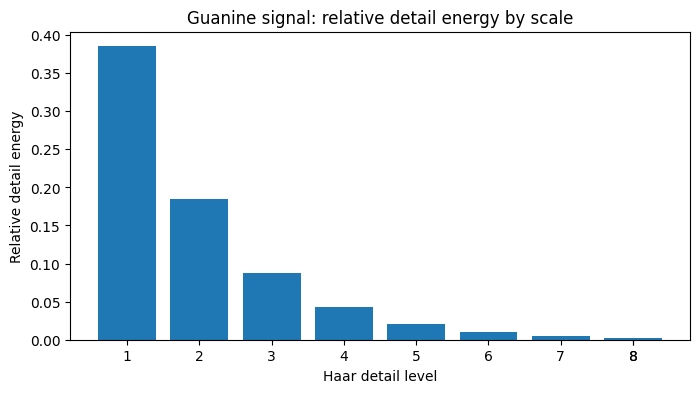

In [15]:
plt.figure(figsize=(8, 4))
plt.bar(g_energy["level"].iloc[1:], g_energy["relative_energy"].iloc[1:])
plt.xlabel("Haar detail level")
plt.ylabel("Relative detail energy")
plt.title("Guanine signal: relative detail energy by scale")
plt.xticks(g_energy["level"])
plt.show()

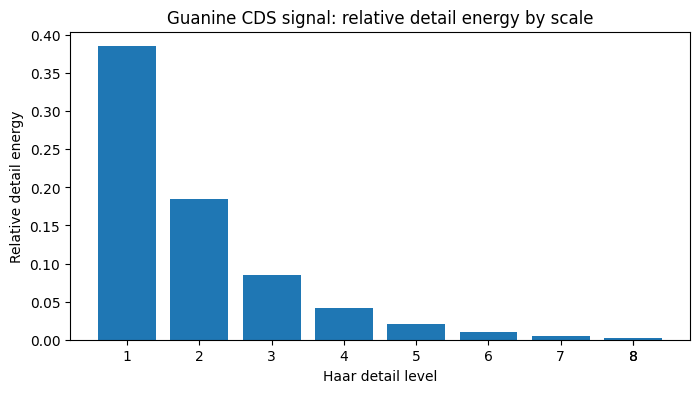

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(g_cds_energy["level"].iloc[1:], g_cds_energy["relative_energy"].iloc[1:])
plt.xlabel("Haar detail level")
plt.ylabel("Relative detail energy")
plt.title("Guanine CDS signal: relative detail energy by scale")
plt.xticks(g_cds_energy["level"])
plt.show()

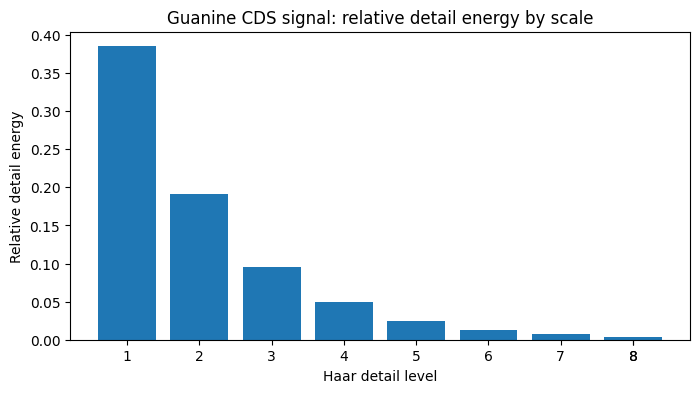

In [17]:
plt.figure(figsize=(8, 4))
plt.bar(g_noncds_energy["level"].iloc[1:], g_noncds_energy["relative_energy"].iloc[1:])
plt.xlabel("Haar detail level")
plt.ylabel("Relative detail energy")
plt.title("Guanine CDS signal: relative detail energy by scale")
plt.xticks(g_noncds_energy["level"])
plt.show()

In [18]:
pd.DataFrame({
    "full": g_energy["relative_energy"][g_energy["kind"]=="detail"],
    "cds": g_cds_energy["relative_energy"][g_cds_energy["kind"]=="detail"],
    "noncds": g_noncds_energy["relative_energy"][g_noncds_energy["kind"]=="detail"],
})

,full,cds,noncds
1,0.385130,0.385148,0.384913
2,0.185108,0.184595,0.190979
3,0.086966,0.085498,0.095874
4,0.042944,0.042138,0.049748
5,0.021091,0.020647,0.024986
6,0.010538,0.010096,0.013020
7,0.005246,0.005016,0.006995
8,0.002872,0.002639,0.004184


CDS vs Non-CDS Energy Comparison

In [19]:
cds_detail_profile = g_cds_detail_energy[["level", "energy"]].copy().sort_values("level", ascending=False)
noncds_detail_profile = g_noncds_detail_energy[["level", "energy"]].copy().sort_values("level", ascending=False)

# Renormalize over detail levels only so the comparison is between detail-energy profiles.
cds_detail_profile["relative_energy"] = cds_detail_profile["energy"] / cds_detail_profile["energy"].sum()
noncds_detail_profile["relative_energy"] = noncds_detail_profile["energy"] / noncds_detail_profile["energy"].sum()
cds_detail_profile["kind"] = "detail"
noncds_detail_profile["kind"] = "detail"

detail_energy_comparison = cds_detail_profile.merge(
    noncds_detail_profile,
    on="level",
    suffixes=("_cds", "_noncds"),
).sort_values("level", ascending=False)

detail_energy_comparison["absolute_difference"] = (
    detail_energy_comparison["relative_energy_cds"]
    - detail_energy_comparison["relative_energy_noncds"]
).abs()

kl_cds_to_noncds = compare_energy_profiles(
    cds_detail_profile,
    noncds_detail_profile,
    column="relative_energy",
    metric="kl",
)
kl_noncds_to_cds = compare_energy_profiles(
    noncds_detail_profile,
    cds_detail_profile,
    column="relative_energy",
    metric="kl",
)
js_cds_noncds = compare_energy_profiles(
    cds_detail_profile,
    noncds_detail_profile,
    column="relative_energy",
    metric="js",
)
l2_cds_noncds = compare_energy_profiles(
    cds_detail_profile,
    noncds_detail_profile,
    column="relative_energy",
    metric="l2",
)
total_variation_cds_noncds = 0.5 * detail_energy_comparison["absolute_difference"].sum()

print("CDS vs non-CDS detail-energy divergence summary")
print(f"KL(CDS || non-CDS): {kl_cds_to_noncds:.6f}")
print(f"KL(non-CDS || CDS): {kl_noncds_to_cds:.6f}")
print(f"JS(CDS, non-CDS): {js_cds_noncds:.6f}")
print(f"L2 distance: {l2_cds_noncds:.6f}")
print(f"Total variation distance: {total_variation_cds_noncds:.6f}")

detail_energy_comparison[[
    "level",
    "relative_energy_cds",
    "relative_energy_noncds",
    "absolute_difference",
]]

CDS vs non-CDS detail-energy divergence summary
KL(CDS || non-CDS): 0.003722
KL(non-CDS || CDS): 0.003918
JS(CDS, non-CDS): 0.000953
L2 distance: 0.027284
Total variation distance: 0.027108


,level,relative_energy_cds,relative_energy_noncds,absolute_difference
0,8,0.003586,0.005429,0.001843
1,7,0.006818,0.009076,0.002259
2,6,0.013722,0.016894,0.003172
3,5,0.028062,0.032420,0.004358
4,4,0.057270,0.064549,0.007279
5,3,0.116201,0.124399,0.008198
6,2,0.250884,0.247800,0.003084
7,1,0.523457,0.499433,0.024024


In [20]:
detail_powerlaw_profiles = {
    "full": g_detail_energy[["level", "energy"]].copy(),
    "CDS": g_cds_detail_energy[["level", "energy"]].copy(),
    "non-CDS": g_noncds_detail_energy[["level", "energy"]].copy(),
}

powerlaw_rows = []
for signal_name, profile in detail_powerlaw_profiles.items():
    fit_df = profile.sort_values("level").copy()
    fit_df["relative_energy"] = fit_df["energy"] / fit_df["energy"].sum()
    fit_df["scale_bp"] = 2 ** fit_df["level"]

    x_log = np.log(fit_df["scale_bp"].to_numpy(dtype=float))
    y_log = np.log(fit_df["relative_energy"].to_numpy(dtype=float))

    power_law_slope, power_law_intercept = np.polyfit(x_log, y_log, 1)
    y_log_hat_power = power_law_slope * x_log + power_law_intercept
    ss_tot = np.sum((y_log - y_log.mean()) ** 2)
    ss_res_power = np.sum((y_log - y_log_hat_power) ** 2)
    power_law_r2 = 1 - ss_res_power / ss_tot if ss_tot > 0 else np.nan

    x_linear = fit_df["scale_bp"].to_numpy(dtype=float)
    exp_slope, exp_intercept = np.polyfit(x_linear, y_log, 1)
    y_log_hat_exp = exp_slope * x_linear + exp_intercept
    ss_res_exp = np.sum((y_log - y_log_hat_exp) ** 2)
    exp_r2 = 1 - ss_res_exp / ss_tot if ss_tot > 0 else np.nan

    powerlaw_rows.append({
        "signal": signal_name,
        "power_law_exponent": power_law_slope,
        "power_law_r2": power_law_r2,
        "semilog_r2": exp_r2,
    })

powerlaw_summary = pd.DataFrame(powerlaw_rows)
print("Detail-energy scaling fit summary")
display(powerlaw_summary)

Detail-energy scaling fit summary


,signal,power_law_exponent,power_law_r2,semilog_r2
0,full,-1.015888,0.999328,0.700482
1,CDS,-1.031060,0.999568,0.705486
2,non-CDS,-0.942299,0.998577,0.689254


Power Law Fit Results: 

Windowed Wavelet Energy

In [21]:
g_windowed_energy = compute_windowed_wavelet_energy(
    g_signal,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
    wavelet="haar",
    level=WINDOW_LEVEL,
    normalize=True,
    include_approximation=False,
)

window_cds = summarize_window_cds_fraction(
    cds_mask,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
)

g_windowed_energy = g_windowed_energy.merge(
    window_cds,
    on=["window_start", "window_end"],
    how="left",
)

g_windowed_energy.head()

NameError: name 'summarize_window_cds_fraction' is not defined

In [ ]:
heatmap_df = (
    g_windowed_energy[g_windowed_energy["kind"] == "detail"]
    .pivot(index="level", columns="window_start", values="relative_energy")
    .sort_index()
)

window_positions = (
    g_windowed_energy[["window_start", "window_end"]]
    .drop_duplicates()
    .sort_values("window_start")
)
x_min = int(window_positions["window_start"].iloc[0])
x_max = int(window_positions["window_end"].iloc[-1])
heatmap_extent = [x_min, x_max, heatmap_df.index.min() - 0.5, heatmap_df.index.max() + 0.5]

region_strip = cds_mask.astype(int).reshape(1, -1)
region_cmap = plt.matplotlib.colors.ListedColormap([
    (0.85, 0.37, 0.01),
    (0.10, 0.62, 0.47),
])

fig, (ax_heatmap, ax_region) = plt.subplots(
    2,
    1,
    figsize=(14, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [12, 1], "hspace": 0.10},
)

im = ax_heatmap.imshow(
    heatmap_df.values,
    aspect="auto",
    origin="lower",
    extent=heatmap_extent,
)
fig.colorbar(im, ax=[ax_heatmap, ax_region], label="Relative detail energy")
ax_heatmap.set_yticks(heatmap_df.index)
ax_heatmap.set_ylabel("Detail level")
ax_heatmap.set_title("Guanine signal: windowed relative detail energy")

ax_region.imshow(
    region_strip,
    aspect="auto",
    origin="lower",
    extent=[0, len(cds_mask), 0, 1],
    cmap=region_cmap,
    vmin=0,
    vmax=1,
)
ax_region.set_xlim(x_min, x_max)
ax_region.set_yticks([])
ax_region.set_ylabel("CDS")
ax_region.set_xlabel("Genome position")
ax_region.set_title("Genome annotation: green = CDS, orange = non-CDS")

plt.show()

In [ ]:
zoom_width = int(1e6)
zoom_center = genome_len // 2
zoom_start = max(0, zoom_center - zoom_width // 2)
zoom_end = min(genome_len, zoom_start + zoom_width)
zoom_start = max(0, zoom_end - zoom_width)

fig, (ax_heatmap, ax_region) = plt.subplots(
    2,
    1,
    figsize=(14, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [12, 1], "hspace": 0.10},
)

im = ax_heatmap.imshow(
    heatmap_df.values,
    aspect="auto",
    origin="lower",
    extent=heatmap_extent,
)
fig.colorbar(im, ax=[ax_heatmap, ax_region], label="Relative detail energy")
ax_heatmap.set_yticks(heatmap_df.index)
ax_heatmap.set_ylabel("Detail level")
ax_heatmap.set_title("Guanine signal: windowed relative detail energy (zoom ~1e6 bp)")
ax_heatmap.set_xlim(zoom_start, zoom_end)

ax_region.imshow(
    region_strip,
    aspect="auto",
    origin="lower",
    extent=[0, len(cds_mask), 0, 1],
    cmap=region_cmap,
    vmin=0,
    vmax=1,
)
ax_region.set_xlim(zoom_start, zoom_end)
ax_region.set_yticks([])
ax_region.set_ylabel("CDS")
ax_region.set_xlabel("Genome position")
ax_region.set_title("Genome annotation: green = CDS, orange = non-CDS")

plt.show()

In [ ]:
zoom_width = int(1e5)
zoom_center = genome_len // 2
zoom_start = max(0, zoom_center - zoom_width // 2)
zoom_end = min(genome_len, zoom_start + zoom_width)
zoom_start = max(0, zoom_end - zoom_width)

fig, (ax_heatmap, ax_region) = plt.subplots(
    2,
    1,
    figsize=(14, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [12, 1], "hspace": 0.10},
)

im = ax_heatmap.imshow(
    heatmap_df.values,
    aspect="auto",
    origin="lower",
    extent=heatmap_extent,
)
fig.colorbar(im, ax=[ax_heatmap, ax_region], label="Relative detail energy")
ax_heatmap.set_yticks(heatmap_df.index)
ax_heatmap.set_ylabel("Detail level")
ax_heatmap.set_title("Guanine signal: windowed relative detail energy (zoom ~1e5 bp)")
ax_heatmap.set_xlim(zoom_start, zoom_end)

ax_region.imshow(
    region_strip,
    aspect="auto",
    origin="lower",
    extent=[0, len(cds_mask), 0, 1],
    cmap=region_cmap,
    vmin=0,
    vmax=1,
)
ax_region.set_xlim(zoom_start, zoom_end)
ax_region.set_yticks([])
ax_region.set_ylabel("CDS")
ax_region.set_xlabel("Genome position")
ax_region.set_title("Genome annotation: green = CDS, orange = non-CDS")

plt.show()

In [ ]:
zoom_width = int(1e5)
zoom_center = genome_len // 2
zoom_start = 2.7 * 1e6
zoom_end = min(genome_len, zoom_start + zoom_width)
zoom_start = max(0, zoom_end - zoom_width)

fig, (ax_heatmap, ax_region) = plt.subplots(
    2,
    1,
    figsize=(14, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [12, 1], "hspace": 0.10},
)

im = ax_heatmap.imshow(
    heatmap_df.values,
    aspect="auto",
    origin="lower",
    extent=heatmap_extent,
)
fig.colorbar(im, ax=[ax_heatmap, ax_region], label="Relative detail energy")
ax_heatmap.set_yticks(heatmap_df.index)
ax_heatmap.set_ylabel("Detail level")
ax_heatmap.set_title("Guanine signal: windowed relative detail energy (zoom ~1e5 bp)")
ax_heatmap.set_xlim(zoom_start, zoom_end)

ax_region.imshow(
    region_strip,
    aspect="auto",
    origin="lower",
    extent=[0, len(cds_mask), 0, 1],
    cmap=region_cmap,
    vmin=0,
    vmax=1,
)
ax_region.set_xlim(zoom_start, zoom_end)
ax_region.set_yticks([])
ax_region.set_ylabel("CDS")
ax_region.set_xlabel("Genome position")
ax_region.set_title("Genome annotation: green = CDS, orange = non-CDS")

plt.show()

In [ ]:
heatmap_cds_df = (
    g_cds_windowed_energy[g_cds_windowed_energy["kind"] == "detail"]
    .pivot(index="level", columns="window_start", values="relative_energy")
    .sort_index()
)

plt.figure(figsize=(14, 4))
plt.imshow(heatmap_cds_df.values, aspect="auto", origin="lower")
plt.colorbar(label="Relative detail energy")
plt.yticks(
    ticks=np.arange(len(heatmap_cds_df.index)),
    labels=heatmap_cds_df.index,
)
plt.xlabel("Window index")
plt.ylabel("Detail level")
plt.title("Guanine CDS signal: windowed relative detail energy")
plt.show()

In [ ]:
heatmap_noncds_df = (
    g_noncds_windowed_energy[g_noncds_windowed_energy["kind"] == "detail"]
    .pivot(index="level", columns="window_start", values="relative_energy")
    .sort_index()
)

plt.figure(figsize=(14, 4))
plt.imshow(heatmap_noncds_df.values, aspect="auto", origin="lower")
plt.colorbar(label="Relative detail energy")
plt.yticks(
    ticks=np.arange(len(heatmap_noncds_df.index)),
    labels=heatmap_noncds_df.index,
)
plt.xlabel("Window index")
plt.ylabel("Detail level")
plt.title("Guanine Non-CDS signal: windowed relative detail energy")
plt.show()

In [ ]:
window_detail_df = g_windowed_energy[g_windowed_energy["kind"] == "detail"].copy()

window_level_correlations = (
    window_detail_df.groupby("level")
    .apply(
        lambda group: pd.Series({
            "pearson_corr": group["cds_fraction"].corr(group["relative_energy"], method="pearson"),
            "spearman_corr": group["cds_fraction"].corr(group["relative_energy"], method="spearman"),
            "mean_relative_energy": group["relative_energy"].mean(),
            "std_relative_energy": group["relative_energy"].std(),
        })
    )
    .reset_index()
    .sort_values("level", ascending=False)
)

window_detail_df["window_class"] = window_detail_df["cds_fraction"].apply(
    lambda x: "CDS" if x >= 0.8 else ("non-CDS" if x <= 0.2 else "mixed")
)

window_distribution_summary = (
    window_detail_df[window_detail_df["window_class"].isin(["CDS", "non-CDS"])]
    .groupby(["level", "window_class"])["relative_energy"]
    .agg([
        "count",
        "mean",
        "std",
        "median",
        lambda s: s.quantile(0.75) - s.quantile(0.25),
    ])
    .rename(columns={"<lambda_0>": "iqr"})
    .reset_index()
)

print("Per-level correlation between CDS fraction and relative detail energy")
display(window_level_correlations)

print("Distribution summary for CDS vs non-CDS windows")
display(window_distribution_summary)

Windowned Energies Results

Figure: Boxplots of Relative Detail Energy by Scale

In [ ]:
def classify_cds_window(cds_fraction: float) -> str:
    if cds_fraction >= 0.8:
        return "CDS"
    if cds_fraction <= 0.2:
        return "non-CDS"
    return "mixed"

g_windowed_energy["window_class"] = g_windowed_energy["cds_fraction"].apply(classify_cds_window)

comparison_df = g_windowed_energy[
    (g_windowed_energy["kind"] == "detail") &
    (g_windowed_energy["window_class"].isin(["CDS", "non-CDS"]))
].copy()

comparison_df.head()

In [ ]:
levels = sorted(comparison_df["level"].unique())
fig, axes = plt.subplots(len(levels), 1, figsize=(8, 2.5 * len(levels)), sharex=True)

if len(levels) == 1:
    axes = [axes]

for ax, level in zip(axes, levels):
    subset = comparison_df[comparison_df["level"] == level]
    groups = [
        subset[subset["window_class"] == "CDS"]["relative_energy"].dropna(),
        subset[subset["window_class"] == "non-CDS"]["relative_energy"].dropna(),
    ]
    ax.boxplot(groups, tick_labels=["CDS", "non-CDS"])
    ax.set_ylabel(f"D{level}")
    ax.set_title(f"Relative detail energy at level {level}")

plt.tight_layout()
plt.show()

Window-Level Entropy of Scale-Energy Distribution

In [ ]:
window_entropy_rows = []

for (window_start, window_end), group in (
    a_windowed_energy[a_windowed_energy["kind"] == "detail"]
    .groupby(["window_start", "window_end"])
):
    entropy = compute_scale_entropy(group, column="relative_energy")
    cds_fraction = float(group["cds_fraction"].iloc[0])
    window_entropy_rows.append({
        "window_start": window_start,
        "window_end": window_end,
        "cds_fraction": cds_fraction,
        "window_class": classify_cds_window(cds_fraction),
        "scale_entropy": entropy,
    })

a_window_entropy = pd.DataFrame(window_entropy_rows)
a_window_entropy.head()

In [ ]:
entropy_compare = a_window_entropy[
    a_window_entropy["window_class"].isin(["CDS", "non-CDS"])
]

plt.figure(figsize=(6, 4))
groups = [
    entropy_compare[entropy_compare["window_class"] == "CDS"]["scale_entropy"].dropna(),
    entropy_compare[entropy_compare["window_class"] == "non-CDS"]["scale_entropy"].dropna(),
]
plt.boxplot(groups, labels=["CDS", "non-CDS"])
plt.ylabel("Scale entropy")
plt.title("Adenine signal: window-level scale entropy")
plt.show()

Let's look at how "significant" the entropy delta is

In [ ]:
entropy_delta = cds_entropy_mean - noncds_entropy_mean
relative_entropy_delta = entropy_delta / cds_entropy_mean
cds_entropy_values = entropy_compare[
    entropy_compare["window_class"] == "CDS"
]["scale_entropy"].dropna().to_numpy()
noncds_entropy_values = entropy_compare[
    entropy_compare["window_class"] == "non-CDS"
]["scale_entropy"].dropna().to_numpy()
n_cds = len(cds_entropy_values)
n_noncds = len(noncds_entropy_values)
pooled_entropy_std = np.sqrt(
    (
        (n_cds - 1) * cds_entropy_std**2
        + (n_noncds - 1) * noncds_entropy_std**2
    )
    / (n_cds + n_noncds - 2)
)
cohens_d_entropy = entropy_delta / pooled_entropy_std
entropy_delta_std = entropy_delta / noncds_entropy_std
print(f"entropy_delta {entropy_delta}, relative_entropy_delta {relative_entropy_delta}")
print(f"entropy_delta_std {entropy_delta_std}")
print(f"cohens_d_entropy {cohens_d_entropy}")